# 고객 Segmentation

고객 세그먼테이션(Customer Segmentation)은 다양한 기준으로 고객을 분류하는 기법이다.
고객 세그먼테이션은 CRM이나 마케팅의 중요 기법 요소중 하나이다.

고객의 다음 속성을 기반으로 세그먼테이션을 수행한다.
- 사는 지역
- 결혼 여부
- 성별
- 소득
- 직업
- 선호 상품군
- 월별 사용액
- VIP 상품 사용 여부
- 최근 구매 상품
- 구매 주기
- 연간 프로모션 참가 횟수
- 고객 분석 요소인 RFM을 적용하여 고객 세그먼테이션 수행

RFM 기법은 Recency(R), Frequency(F), Monetary Value(M)의 각 앞글자를 합한 것으로 의미는 다음과 같다.

- RECENCY (R): 가장 최근 상품 구입 일에서 오늘까지의 기간
- FREQUENCY (F): 상품 구매 횟수
- MONETARY VALUE (M): 총 구매 금액

## UCI 온라인 판매
https://archive.ics.uci.edu/dataset/352/online+retail

| 변수명 | 유형 | 설명 |  |
| --- | --- | --- | --- |
| InvoiceNo | 범주형 | 각 거래에 고유하게 부여된 6자리 숫자. 'C'로 시작하면 거래 취소를 의미함. |  |
| StockCode | 범주형 | 각 제품에 고유하게 부여된 5자리 숫자 코드. |  |
| Description | 범주형 | 제품의 이름. |  |
| Quantity | 정수형 | 거래당 각 제품의 수량. |  |
| InvoiceDate | 날짜/시간형 | 거래가 발생한 날짜와 시간. |  |
| UnitPrice | 연속형 | 제품 단가 (영국 파운드화 기준). |  |
| CustomerID | 범주형 | 각 고객에게 고유하게 부여된 5자리 숫자. |  |
| Country | 범주형 | 고객이 거주하는 국가명. |  |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
# %conda install openpyxl

In [2]:
# 데이터로드
retail_df = pd.read_excel('data/Online Retail.xlsx')
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
retail_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### 데이터 전처리
- 결측치 탐지/처리
- 이상치 탐지/처리
- 불필요한 컬럼 제거

In [ ]:
# 결제 취소 건 확인
retail_df['InvoiceNo'].apply(type).value_counts()   # 'int', 'str' 섞여 있음
print(retail_df['InvoiceNo'].astype(str).str.startswith('C'))   # 명시적 형변환 후 처리
# 주문 수량이 0 이하인 건 확인
print((retail_df['Quantity'] <= 0).sum())
# 단위 가격이 0 이하인 건 확인
print((retail_df['UnitPrice'] <= 0).sum())
# 고객 ID 결측 건 확인
print(retail_df['CustomerID'].isnull().sum())


0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Name: InvoiceNo, Length: 541909, dtype: bool
10624


In [12]:
# 위에서 관찰 된 행 제거
retail_df = retail_df[~retail_df['InvoiceNo'].astype(str).str.startswith('C')]
retail_df = retail_df[retail_df['Quantity'] >0]
retail_df = retail_df[retail_df['UnitPrice'] >0]
retail_df = retail_df[retail_df['CustomerID'].notnull()]

In [13]:
# 제거 완료 확인
retail_df['InvoiceNo'].apply(type).value_counts()   
print(retail_df['InvoiceNo'].astype(str).str.startswith('C')) 
print((retail_df['Quantity'] <= 0).sum())
print((retail_df['UnitPrice'] <= 0).sum())
print(retail_df['CustomerID'].isnull().sum())

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Name: InvoiceNo, Length: 397884, dtype: bool
0
0
0


In [14]:
# 국가
print(retail_df['Country'].value_counts())

# 영국 데이터만 사용
retail_df = retail_df[retail_df['Country'] == 'United Kingdom']

Country
United Kingdom          354321
Germany                   9040
France                    8341
EIRE                      7236
Spain                     2484
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1462
Australia                 1182
Norway                    1071
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     248
Unspecified                244
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


### RFM 기반 데이터 가공
- Recency: 최근 구매일기준
- Frequency: 고객별 구매건수
- Monetary Value: 총구매가격 (단위가격 * 수량)

In [17]:
# 구매 가격
retail_df['SaleAmount'] = retail_df['UnitPrice'] * retail_df['Quantity']
retail_df[['UnitPrice', 'Quantity', 'SaleAmount']].head()

,UnitPrice,Quantity,SaleAmount
0,6,6,36
1,6,6,36
2,8,8,64
3,6,6,36
4,6,6,36


In [ ]:
# 고객별 구매 금액
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)
print(retail_df['CustomerID'].value_counts())   # 고객별 구매 건수

retail_df.groupby('CustomerID')['SaleAmount'].sum().sort_values(ascending=False)[:10] # 고객별 총 구매 금액


CustomerID
17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
         ... 
18084       1
18184       1
13017       1
18174       1
15195       1
Name: count, Length: 3920, dtype: int64


In [21]:
# RFM
cust_df = retail_df.groupby('CustomerID').agg({
    'InvoiceDate' : 'max',
    'InvoiceNo' : 'count',
    'SaleAmount' : 'sum'
})

cust_df =cust_df.rename(columns={
    'InvoiceDate' : 'Recency',
    'InvoiceNo' : 'Frequency',
    'SaleAmount' : 'Monetary'
})

cust_df

,Recency,Frequency,Monetary
CustomerID,,,
12346,2011-01-18 10:01:00,1,5507866225
12747,2011-12-07 14:34:00,103,25677
12748,2011-12-09 12:20:00,4595,1654855
12749,2011-12-06 09:56:00,199,22877
12820,2011-12-06 15:12:00,59,12440
...,...,...,...
18280,2011-03-07 09:52:00,10,235
18281,2011-06-12 10:53:00,7,570
18282,2011-12-02 11:43:00,12,2707


In [22]:
# 고객의 마지막 구매일을 기준일과 비교하여 각 고객이 마지막으로 구매한 뒤 몇 일이 지났는지 숫자형으로 변환
snapshot_data = retail_df['InvoiceDate'].max() + pd.Timedelta(days=1)
cust_df['Recency'] = (snapshot_data - cust_df['Recency']).dt.days

### RFM 고객 분류

In [23]:
# RFM 값 분포
cust_df.describe()

,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3.920000e+03
mean,92.208418,90.388010,3.250948e+06
std,99.533854,217.808385,1.368017e+08
min,1.000000,1.000000,1.000000e+00
25%,18.000000,17.000000,2.097000e+03
50%,51.000000,41.000000,6.600000e+03
75%,143.000000,99.250000,2.345925e+04
max,374.000000,7847.000000,6.560190e+09


Text(0.5, 1.0, 'Monetary')

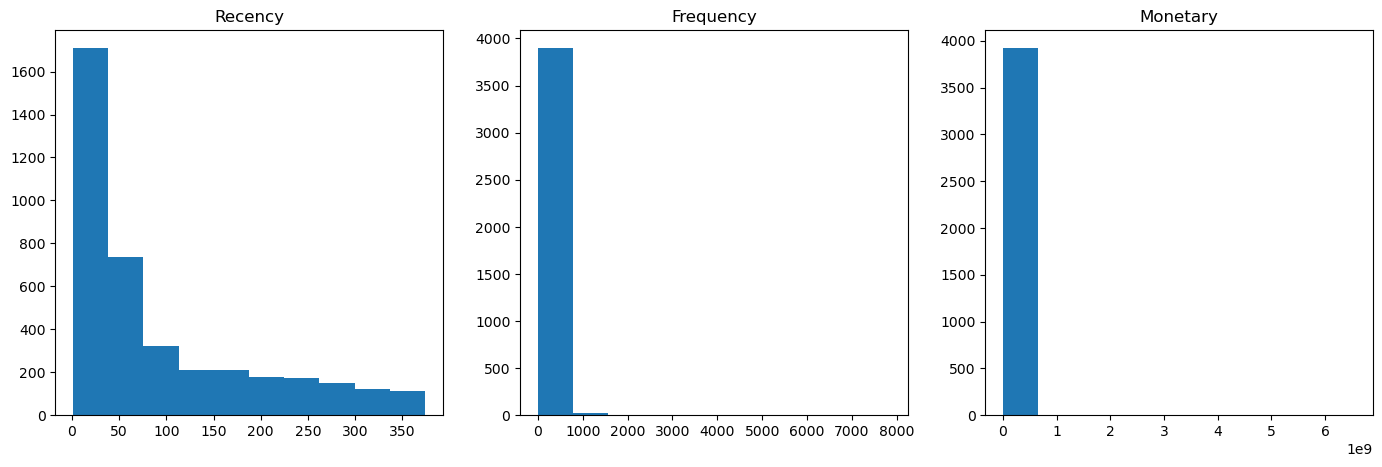

In [24]:
fig, ax = plt.subplots(1,3, figsize=(17,5))

ax[0].hist(cust_df['Recency'])
ax[0].set_title('Recency')

ax[1].hist(cust_df['Frequency'])
ax[1].set_title('Frequency')

ax[2].hist(cust_df['Monetary'])
ax[2].set_title('Monetary')

In [25]:
# 로그변환
# RFM 값은 보통 한쪽으로 치우친 분포를 가지기 쉬우므로 로그 변환을 통해
# 값이 큰 구간은 더 강하게 눌러주고, 작은 값 구간의 차이는 비교적 유지할 수 있도록 한다.

cust_df['Recency'] = np.log1p(cust_df['Recency'])
cust_df['Frequency'] = np.log1p(cust_df['Frequency'])
cust_df['Monetary'] = np.log1p(cust_df['Monetary'])

cust_df.describe()

,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,3.827566,3.721360,8.860835
std,1.340816,1.260138,2.075261
min,0.693147,0.693147,0.693147
25%,2.944439,2.890372,7.648740
50%,3.951244,3.737670,8.794976
75%,4.969813,4.607658,10.063063
max,5.926926,8.968014,22.604285


Text(0.5, 1.0, 'Monetary')

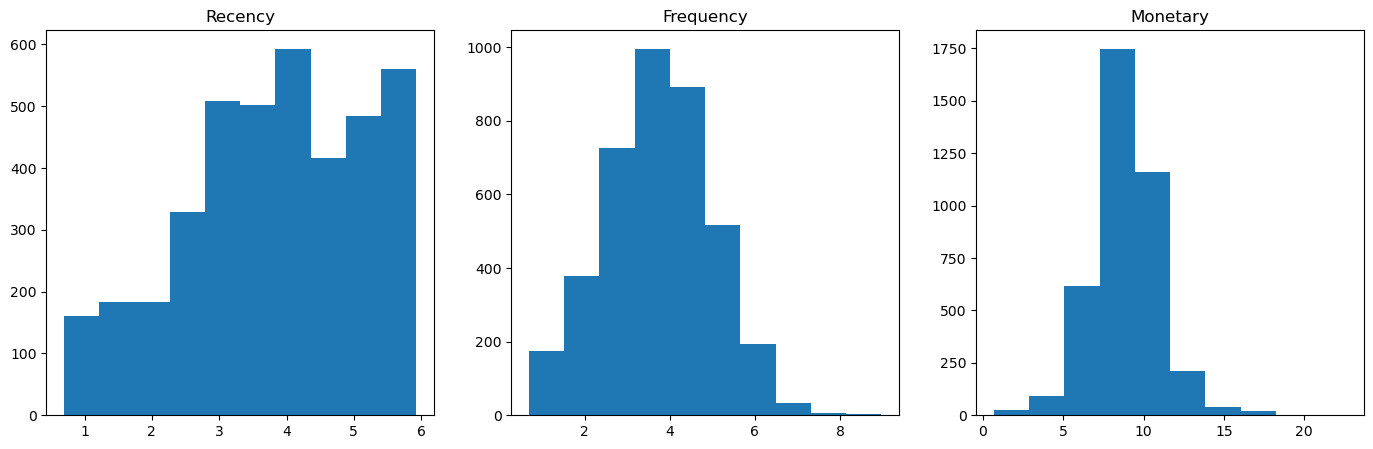

In [26]:
fig, ax = plt.subplots(1,3, figsize=(17,5))

ax[0].hist(cust_df['Recency'])
ax[0].set_title('Recency')

ax[1].hist(cust_df['Frequency'])
ax[1].set_title('Frequency')

ax[2].hist(cust_df['Monetary'])
ax[2].set_title('Monetary')

### 군집화

In [28]:
from sklearn.cluster import KMeans
Kmeans = KMeans(n_clusters=3, random_state=42)
labels = Kmeans.fit_predict(cust_df)

cust_df['cluster'] = labels
cust_df

,Recency,Frequency,Monetary,cluster
CustomerID,,,,
12346,5.789960,0.693147,22.429443,1
12747,1.098612,4.644391,10.153390,1
12748,0.693147,8.432942,14.319225,1
12749,1.609438,5.298317,10.037931,1
12820,1.386294,4.094345,9.428753,1
...,...,...,...,...
18280,5.631212,2.397895,5.463832,0
18281,5.204007,2.079442,6.347389,0
18282,2.197225,2.564949,7.903966,2


In [29]:
# inertia (Elbow method)
inertias = []

for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = Kmeans.fit_predict(cust_df.iloc[:,:-1])
    inertias.append(kmeans.inertia_)

plt.plot(range(2,7),inertias)
plt.show()

AttributeError: 'KMeans' object has no attribute 'inertia_'

In [ ]:
# 실루엣 계수
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,7):
    kmeans =KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(cust_df.iloc[:,:-1])
    sil_scores.append(silhouette_score(cust_df.iloc[:,:-1], labels))

plt.plot(range(2,7), sil_scores)
plt.show()

### 클러스터별 페르소나 분석
- 정량 지표와 비즈니스 해석을 함께 고려해서 군집 개수 설정

In [30]:
from sklearn.cluster import KMeans
# 군집화에 사용할 특성만 선택
rfm_features = cust_df[['Recency','Frequency','Monetary']]

# 고객 세분화를 위해 군집 5개로 클러스터링
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(rfm_features)

# 군집 결과 원본 데이터 저장
cust_df['cluster'] = labels
cust_df.head()

,Recency,Frequency,Monetary,cluster
CustomerID,,,,
12346,5.789960,0.693147,22.429443,4
12747,1.098612,4.644391,10.153390,1
12748,0.693147,8.432942,14.319225,4
12749,1.609438,5.298317,10.037931,1
12820,1.386294,4.094345,9.428753,1


In [31]:
# 클러스터별 평균
cluster_summary = cust_df.groupby('cluster').agg(
    count=('Recency','count'),
    recency_mean = ('Recency', 'mean'),
    frequency_mean = ('Frequency','mean'),
    monetary_mean=('Monetary', 'mean')
).reset_index().round(2)

cluster_summary

,cluster,count,recency_mean,frequency_mean,monetary_mean
0,0,508,4.81,2.45,5.62
1,1,994,2.49,4.61,9.25
2,2,1326,4.55,3.20,8.00
3,3,734,4.36,3.70,10.33
4,4,358,2.36,5.04,12.58


### RFM 클러스터링 결과를 바탕으로 한 클러스터별 페르소나 분석
- Cluster 0 : 최근성, 구매 빈도, 구매 금액이 모두 낮은 편이다. => 저활동 고객, 휴면 고객
- Cluster 1 : 구매 빈도와 금액이 높은 편이며, 최근성도 비교적 양호하다. => 잠재 VIP, 우수 고객
- Cluster 2 : 최근성은 좋은 편이지만 구매 빈도와 금액이 중간 수준이다. => 활성 고객, 성장 가능성 고객
- Cluster 3 : 최근에도 구매했고, 구매 빈도와 구매 금액도 가장 높다. => 핵심 VIP 고객
- Cluster 4 : 구매 빈도와 금액이 아주 낮지는 않지만 최근성이 떨어진다. => 이탈 위험 고객